#### Import all the necesary libraries

In [1]:
import praw
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, classification_report
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Attention, Concatenate
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns

#### Sentiment Analyzer

In [2]:
# Initialize Sentiment Analyzer
# nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

#### Scrape Reddit Data by setting up Reddit API credentials

In [3]:
# Set up Reddit API credentials
reddit = praw.Reddit(
    client_id="61G5r3qum5peFaRdvtbMJg",
    client_secret="yPzjWBhh797nj2muWQJt3jAEhtZtqg",
    user_agent="script by u/Educational_Leek_918"
)

# Scrape Reddit Data
def scrape_reddit(subreddits, limit=500):
    posts = []
    for subreddit in subreddits:
        subreddit_data = reddit.subreddit(subreddit).hot(limit=limit)
        for post in subreddit_data:
            posts.append({
                'title': post.title,
                'selftext': post.selftext,
                'score': post.score,
                'num_comments': post.num_comments,
                'created_utc': post.created_utc
            })
    return pd.DataFrame(posts)

# Scrape relevant subreddits
subreddits = ['stocks', 'investing', 'WallStreetBets']
reddit_data = scrape_reddit(subreddits)

#### Data Preprocessing and Label Creation

In [4]:
# Preprocess Data
def preprocess_reddit_data(data):
    data['text'] = data['title'] + ' ' + data['selftext']
    data['text'] = data['text'].apply(lambda x: re.sub(r'\n|\r|\t', ' ', x))  # Remove line breaks
    data['text'] = data['text'].str.lower()  # Convert to lowercase
    data['sentiment'] = data['text'].apply(lambda x: sia.polarity_scores(x)['compound'])  # Sentiment
    data['tickers'] = data['text'].apply(lambda x: re.findall(r'\$\w+', x))  # Extract tickers
    data['num_tickers'] = data['tickers'].apply(len)  # Count tickers
    return data

reddit_data = preprocess_reddit_data(reddit_data)

# Add TF-IDF Features
vectorizer = TfidfVectorizer(max_features=100)
tfidf_matrix = vectorizer.fit_transform(reddit_data['text'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
reddit_data = pd.concat([reddit_data.reset_index(drop=True), tfidf_df], axis=1)

# Label Creation (Simplified: Predict Up/Down Movement Based on Sentiment)
reddit_data['label'] = reddit_data['sentiment'].apply(lambda x: 1 if x > 0 else 0)

#### Splitting the data

In [5]:
# Split Data
X = reddit_data.drop(['label', 'title', 'selftext', 'text', 'tickers'], axis=1)
y = reddit_data['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### LSTM Architecture and Model Training

In [6]:
# Build LSTM with Attention Mechanism
def build_model(input_dim):
    inputs = Input(shape=(input_dim,))
    dense1 = Dense(128, activation='relu')(inputs)
    dense2 = Dense(64, activation='relu')(dense1)
    lstm_out = tf.keras.layers.Reshape((64, 1))(dense2)
    lstm = LSTM(64, return_sequences=True)(lstm_out)
    attention = Attention()([lstm, lstm])
    flat = tf.keras.layers.Flatten()(attention)
    dense3 = Dense(32, activation='relu')(flat)
    output = Dense(1, activation='sigmoid')(dense3)
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = build_model(X_train.shape[1])
model.summary()

# Convert to NumPy arrays
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

# Train Model
history = model.fit(X_train_np, y_train_np, validation_data=(X_test_np, y_test_np), epochs=10, batch_size=32)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 105)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 128)               │          13,568 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 64)                │           8,256 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape (Reshape)             │ (None, 64, 1)             │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm (LSTM)                   │ (None, 64, 64)            │          16,896 │ reshape[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention (Attention)         │ (None, 64, 64)            │               0 │ lstm[0][0], lstm[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 4096)              │               0 │ attention[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 32)                │         131,104 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 1)                 │              33 │ dense_2[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 169,857 (663.50 KB)

 Trainable params: 169,857 (663.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.6983 - loss: 0.6418 - val_accuracy: 0.6833 - val_loss: 0.6245
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6983 - loss: 0.6214 - val_accuracy: 0.6833 - val_loss: 0.6562
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.6983 - loss: 0.6194 - val_accuracy: 0.6833 - val_loss: 0.6245
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.6983 - loss: 0.6155 - val_accuracy: 0.6833 - val_loss: 0.6321
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.6983 - loss: 0.6248 - val_accuracy: 0.6833 - val_loss: 0.6280
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.6983 - loss: 0.6189 - val_accuracy: 0.6833 - val_loss: 0.6309
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.6983 - loss: 0.6222 - val_accuracy: 0.6833 - val_loss: 0.6354
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.6983 - loss: 0.6202 - val_accuracy: 0.6833 - v

#### Prediction and Evaluation

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
Root Mean Squared Error: 0.5627314338711378
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        95
           1       0.68      1.00      0.81       205

    accuracy                           0.68       300
   macro avg       0.34      0.50      0.41       300
weighted avg       0.47      0.68      0.55       300



C:\Users\91939\anaconda3\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\91939\anaconda3\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\91939\anaconda3\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

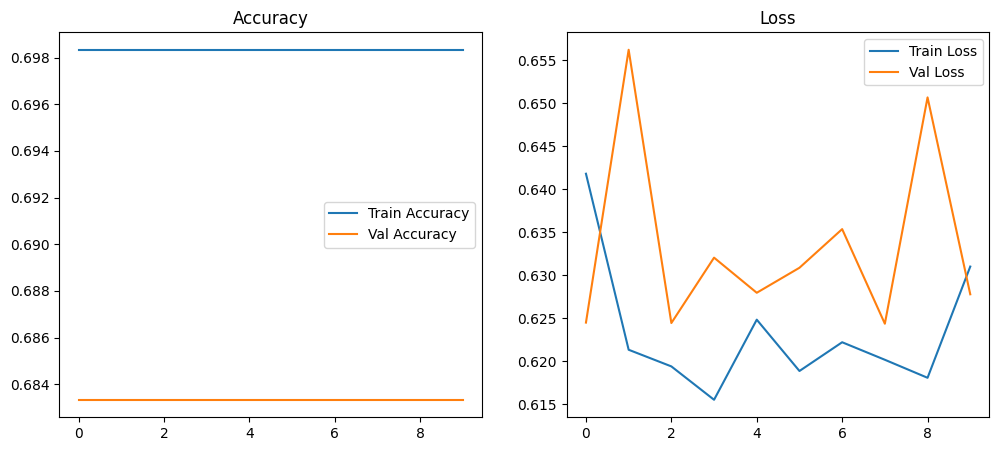

In [7]:
# Prediction
y_pred = (model.predict(X_test_np) > 0.5).astype(int)

# Evaluation
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test_np, y_pred)))
print(classification_report(y_test_np, y_pred))

# Plot Model Accuracy and Loss
def plot_history(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.legend()
    plt.title('Accuracy')
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title('Loss')
    plt.show()

plot_history(history)